##**Problem Statement : **
Predict whether a customer will make a purchase based on their browsing behavior on an e-commerce website.

In [93]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [94]:
#Load the dataset
df = pd.read_csv("/content/ecommerce.csv")

In [95]:
df.head()

,time_spent_minutes,pages_viewed,products_viewed,items_added_to_cart,device_type,traffic_source,is_returning_customer,discount_used,previous_purchases,average_cart_value,purchase
0,10.94,9,5,2,Desktop,Direct,0,1,0,1598.73,0
1,15.11,9,6,2,Desktop,Ads,1,1,7,3073.28,1
2,16.67,9,5,2,Mobile,Google,1,1,4,2342.22,0
3,22.54,12,8,3,Desktop,Ads,1,1,3,2975.04,1
4,9.64,6,4,1,Desktop,Ads,0,0,0,715.49,0


In [96]:
# Check shape (rows, columns)
df.shape

(500, 11)

In [97]:
# Check data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   time_spent_minutes     492 non-null    float64
 1   pages_viewed           500 non-null    int64  
 2   products_viewed        500 non-null    int64  
 3   items_added_to_cart    500 non-null    int64  
 4   device_type            500 non-null    object 
 5   traffic_source         500 non-null    object 
 6   is_returning_customer  500 non-null    int64  
 7   discount_used          500 non-null    int64  
 8   previous_purchases     500 non-null    int64  
 9   average_cart_value     492 non-null    float64
 10  purchase               500 non-null    int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 43.1+ KB


In [98]:
#Missing Values
df.isnull().sum()

,0
time_spent_minutes,8
pages_viewed,0
products_viewed,0
items_added_to_cart,0
device_type,0
traffic_source,0
is_returning_customer,0
discount_used,0
previous_purchases,0
average_cart_value,8


In [99]:
# Statistical summary
df.describe()

,time_spent_minutes,pages_viewed,products_viewed,items_added_to_cart,is_returning_customer,discount_used,previous_purchases,average_cart_value,purchase
count,492.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,492.000000,500.000000
mean,20.601260,10.896000,7.392000,2.948000,0.586000,0.794000,2.648000,2890.780061,0.500000
std,10.609591,5.133604,3.454592,1.686114,0.493042,0.404836,2.599541,1439.077878,0.500501
min,-2.110000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-159.530000,0.000000
25%,12.625000,7.000000,5.000000,2.000000,0.000000,1.000000,0.000000,1791.675000,0.000000
50%,18.680000,11.000000,7.000000,3.000000,1.000000,1.000000,2.000000,2803.380000,0.500000
75%,27.352500,14.000000,10.000000,4.000000,1.000000,1.000000,5.000000,3835.565000,1.000000
max,51.790000,27.000000,17.000000,8.000000,1.000000,1.000000,7.000000,7184.430000,1.000000


In [100]:
# fill float columns with mean
df["time_spent_minutes"].fillna(df["time_spent_minutes"].mean(), inplace=True)
df["average_cart_value"].fillna(df["average_cart_value"].mean(), inplace=True)
print(df.isnull().sum())

time_spent_minutes       0
pages_viewed             0
products_viewed          0
items_added_to_cart      0
device_type              0
traffic_source           0
is_returning_customer    0
discount_used            0
previous_purchases       0
average_cart_value       0
purchase                 0
dtype: int64


Univariate Analysis

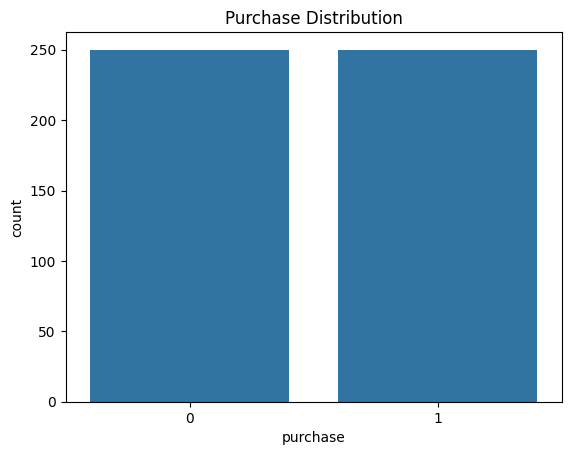

In [113]:
sns.countplot(x="purchase", data=df)
plt.title("Purchase Distribution")
plt.show()

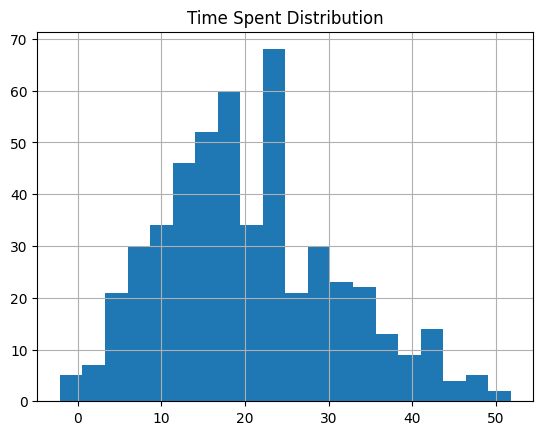

In [112]:
df["time_spent_minutes"].hist(bins=20)
plt.title("Time Spent Distribution")
plt.show()

Bivariate Analysis

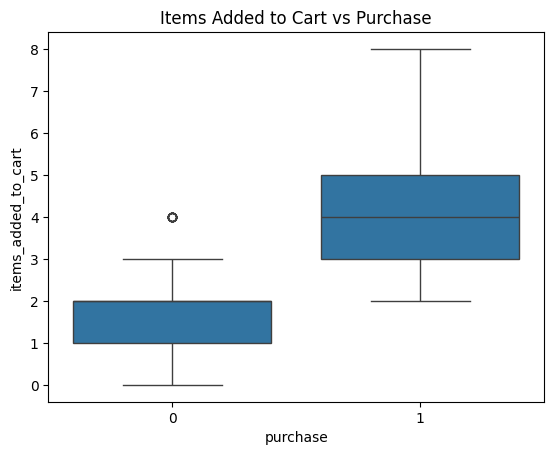

In [110]:

sns.boxplot(x="purchase", y="items_added_to_cart", data=df)
plt.title("Items Added to Cart vs Purchase")
plt.show()


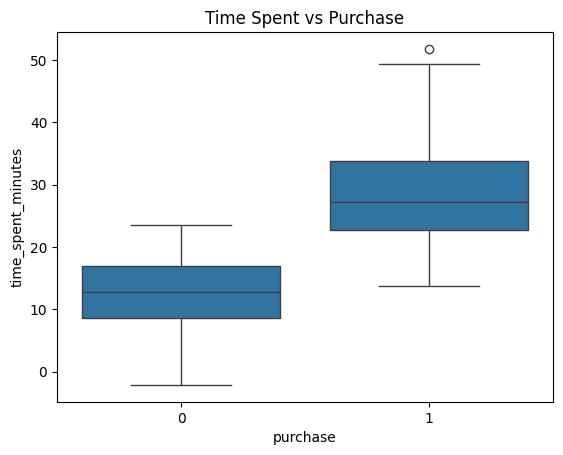

In [109]:
sns.boxplot(x="purchase", y="time_spent_minutes", data=df)
plt.title("Time Spent vs Purchase")
plt.show()


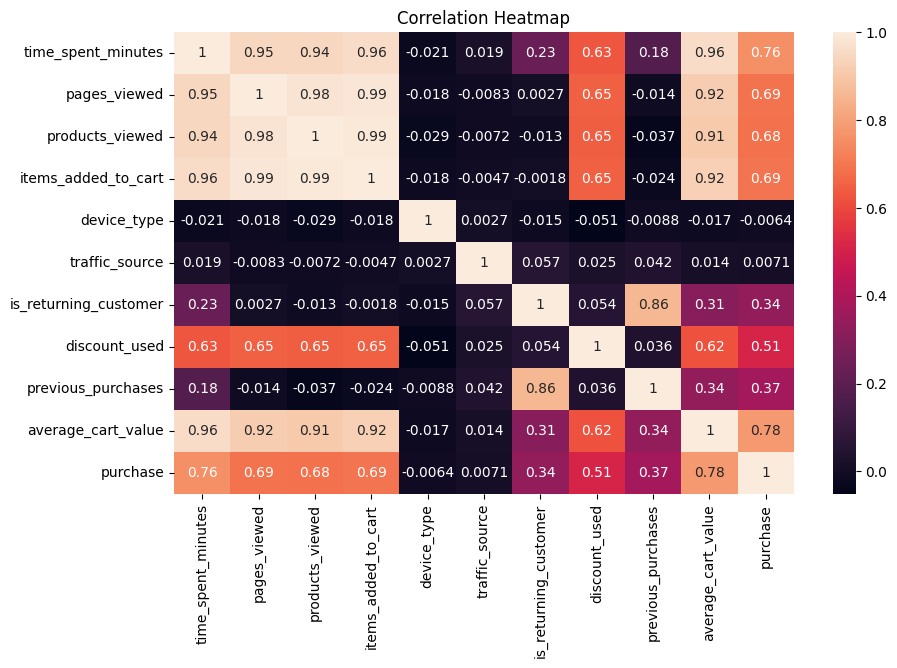

In [111]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [117]:
# Check outliers for numerical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    if col != "purchase":   # don't check target
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        print(f"{col}: {len(outliers)} outliers")

time_spent_minutes: 2 outliers
pages_viewed: 1 outliers
products_viewed: 0 outliers
items_added_to_cart: 1 outliers
device_type: 0 outliers
traffic_source: 0 outliers
is_returning_customer: 0 outliers
discount_used: 103 outliers
previous_purchases: 0 outliers
average_cart_value: 3 outliers


In [118]:
for col in numerical_cols:
    if col != "purchase":
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[
            (df[col] >= lower_bound) &
            (df[col] <= upper_bound)
        ]

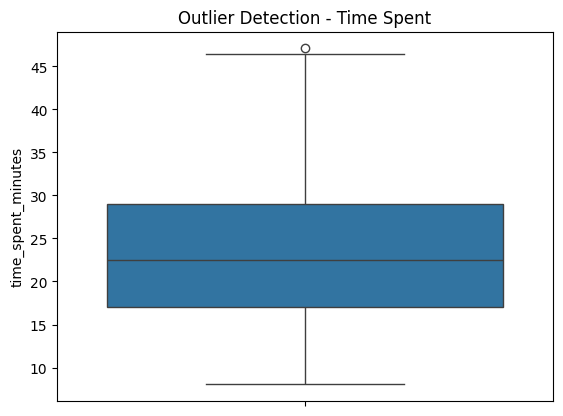

In [119]:
sns.boxplot(y=df["time_spent_minutes"])
plt.title("Outlier Detection - Time Spent")
plt.show()

In [101]:
#Encode categorical columns
le = LabelEncoder()
df["device_type"] = le.fit_transform(df["device_type"])
df["traffic_source"] = le.fit_transform(df["traffic_source"])

In [102]:
#Split X and y
X = df.drop("purchase", axis=1)
y = df["purchase"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [103]:
#Random Forest model
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=300, random_state=42)

In [115]:
#Import
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_squared_error,
    precision_score,
    recall_score
)

In [116]:
#Accuracy
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("MSE:", mse)
print("Precision:", precision)
print("Recall:", recall)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.98
MSE: 0.02
Precision: 0.9811320754716981
Recall: 0.9811320754716981

Confusion Matrix:
[[46  1]
 [ 1 52]]
